# GPT-assisted anlysis

In [1]:
import os
import json
import random
import torch
import torch.nn.functional as F
import numpy as np
from collections import defaultdict
from typing import List, Dict, Tuple, Any
import spacy
from PIL import Image
from tqdm import tqdm

from transformers import (
    InstructBlipProcessor, 
    InstructBlipForConditionalGeneration,
    LlavaForConditionalGeneration, 
    BitsAndBytesConfig,
    AutoModelForCausalLM,
    Qwen2VLForConditionalGeneration,
    AutoProcessor,
    AutoTokenizer
)

model_names = {
    "instructblip": "Salesforce/instructblip-vicuna-7b",
    "llava": "llava-hf/llava-1.5-7b-hf",
    "qwen2-vl": "Qwen/Qwen2-VL-7B-Instruct"
}

model_type = "instructblip"
cache_dir = "/scratch/mfazli/huggingface_cache"
device = "cuda" if torch.cuda.is_available() else "cpu"


def process_inputs(raw_image, query, processor, model, model_type):
    """
    Process inputs depending on the model (e.g., InstructBLIP or LLaVA).
    """

    if model_type == "llava":
        conversation = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": query},
                ],
            }
        ]
        text_prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)
        inputs = processor(images=raw_image, text=text_prompt, padding=True, return_tensors="pt").to(model.device, torch.float16)
    elif model_type == "instructblip":  # InstructBLIP
        inputs = processor(images=raw_image, text=query, return_tensors="pt").to(model.device)
    
    elif model_type == "qwen2-vl":
        
        conversation = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": raw_image},
                    {"type": "text", "text": query}
                ]
            }
        ]        
        
        text_prompt = processor.apply_chat_template(conversation, add_generation_prompt=True, tokenize=False)
        inputs = processor(text=text_prompt, images=image, return_tensors="pt").to(model.device)
    
    else:
        raise ValueError("Model type not detected. Use 'llava' or 'instructblip'")

    return inputs


def load_model_and_processor(model_type, model_names, cache_dir, device):
    
    quantization_config = BitsAndBytesConfig(load_in_8bit=True,
                                         llm_int8_threshold=200.0)
    
    if model_type == "instructblip":
        model = InstructBlipForConditionalGeneration.from_pretrained(
            model_names[model_type], 
            torch_dtype=torch.float16,
            attn_implementation="eager", 
            cache_dir=cache_dir,
            quantization_config=quantization_config,
            device_map="auto")
        model.tie_weights()
        
        processor = InstructBlipProcessor.from_pretrained(
            model_names[model_type], 
            cache_dir=cache_dir
        )
        
    elif model_type == "llava":
        model = LlavaForConditionalGeneration.from_pretrained(
            model_names[model_type], 
            torch_dtype=torch.float16,
            attn_implementation="eager", 
            cache_dir=cache_dir,
            quantization_config=quantization_config,
            device_map="auto")   
        
        processor = AutoProcessor.from_pretrained(
            model_names[model_type],
            cache_dir=cache_dir
        )
        
        processor.patch_size = model.config.vision_config.patch_size
        processor.vision_feature_select_strategy = model.config.vision_feature_select_strategy     
    
    elif model_type == "qwen2-vl":
        model = Qwen2VLForConditionalGeneration.from_pretrained(
            model_names[model_type],
            torch_dtype=torch.float16,
            device_map="auto",
            cache_dir=cache_dir
        )
        processor = AutoProcessor.from_pretrained(
            model_names[model_type],
            cache_dir=cache_dir
        )
        
    else:
        raise ValueError

    return model, processor

In [70]:
import os
import json
import random
import torch
import torch.nn.functional as F
import numpy as np
from collections import defaultdict
from typing import List, Dict, Any
import spacy
from PIL import Image

# ---------------------------------------------------
# Data Sampling & Storage
# ---------------------------------------------------
class DataSampler:
    def __init__(self, captions_file: str, sample_size: int = 100, seed: int = 42):
        """
        captions_file: JSONL with fields {'image_id', 'caption'}
        """
        self.captions_file = captions_file
        self.sample_size = sample_size
        random.seed(seed)

    def sample(self) -> List[Dict[str, Any]]:
        """
        Returns a list of samples: each sample is a dict with keys:
          - 'image_id', 'caption'
        """
        all_samples = []
        with open(self.captions_file) as f:
            for line in f:
                all_samples.append(json.loads(line))
        random.shuffle(all_samples)
        return all_samples[: self.sample_size]

# ---------------------------------------------------
# Token Classification: function vs content vs punctuation
# ---------------------------------------------------
class TokenClassifier:
    def __init__(self, lang_model: str = 'en_core_web_sm'):
        self.nlp = spacy.load(lang_model, disable=['parser', 'ner'])
        self.open_pos = {'NOUN', 'VERB', 'ADJ', 'ADV', 'PROPN'}

    def classify(self, token_str: str) -> str:
        """Return 'content', 'function', or 'punctuation' for a token string."""
        doc = self.nlp(token_str)
        if not doc:
            return 'function'
        pos = doc[0].pos_
        if pos == 'PUNCT':
            return 'punctuation'
        if pos in self.open_pos:
            return 'content'
        return 'function'

# ---------------------------------------------------
# Prefix Truncation Utility
# ---------------------------------------------------
# ---------------------------------------------------
# Prefix Truncation Utility (string-based, no tokenizer)
# ---------------------------------------------------
class PrefixTruncator:
    def __init__(self, tokenizer=None):
        pass

    def truncate(self, caption: str, target_word: str) -> str:
        """
        Return the prefix text up to (not including) the first occurrence of target_word.
        Works via simple string find to avoid tokenizer issues.
        """
        idx = caption.find(target_word)
        if idx == -1:
            return caption
        return caption[:idx]

# ---------------------------------------------------
# Forward Passes (with/without image) & Logits Extraction
# ---------------------------------------------------
class ForwardProcessor:
    def __init__(self, model, processor, model_type: str):
        self.model = model.eval()
        # If InstructBLIP: disable image_token_index to avoid empty mask errors
        if hasattr(self.model.config, 'image_token_index'):
            self.model.config.image_token_index = None
        self.processor = processor
        self.model_type = model_type

    def run(self,
            raw_image: Image.Image,
            prefix_text: str,
            mask_image: bool = False,
            output_layers: bool = False
        ) -> Dict[str, Any]:
        """
        Runs a single forward pass. Uses shared process_inputs for all LVLMs.
        Returns:
          - 'logits': Tensor[vocab_size]
          - 'layer_states': List[Tensor[hidden_dim]] if output_layers
        """
        from model_utils import process_inputs
        inputs = process_inputs(
            raw_image,
            prefix_text,
            self.processor,
            self.model_type,
            self.model.device
        )
        if mask_image:
            inputs['pixel_values'] = inputs['pixel_values'] * 0

        with torch.no_grad():
            outputs = self.model(
                **inputs,
                output_hidden_states=output_layers,
                return_dict=True
            )
        lm_out = (outputs.language_model_outputs
                  if hasattr(outputs, 'language_model_outputs') else outputs)
        logits = lm_out.logits[0, -1, :].cpu()
        result = {'logits': logits}
        if output_layers:
            hiddens = lm_out.hidden_states
            result['layer_states'] = [h[0, -1, :].cpu() for h in hiddens]
        return result

# ---------------------------------------------------
# Analysis Methods
# ---------------------------------------------------
class Analyzer:
    def __init__(self, forwarder: ForwardProcessor, tokenizer, classifier: TokenClassifier = None):
        self.fwd = forwarder
        self.tokenizer = tokenizer
        self.classifier = classifier or TokenClassifier()

    def compute_similarity(self, logit_a: torch.Tensor, logit_b: torch.Tensor, measure: str='js') -> float:
        p = F.softmax(logit_a, dim=-1)
        q = F.softmax(logit_b, dim=-1)
        eps = 1e-6
        p = (p + eps) / (p.sum() + eps * p.numel())
        q = (q + eps) / (q.sum() + eps * q.numel())
        if measure == 'cos':
            return float(F.cosine_similarity(p, q, dim=0).item())
        if measure == 'kl':
            return float(torch.sum(p * (p.log() - q.log())).item())
        if measure == 'js':
            m = 0.5 * (p + q)
            return float((0.5 * torch.sum(p * (p.log() - m.log())) +
                          0.5 * torch.sum(q * (q.log() - m.log()))).item())
        raise ValueError(f"Unknown measure: {measure}")

    def run_logit_similarity(
        self,
        samples: List[Dict[str, Any]],
        token_labels: Dict[int, Dict[str, List[str]]],
        measure: str='js'
    ) -> Dict[str, List[float]]:
        results = {'content': [], 'function': [], 'punctuation': []}
        truncator = PrefixTruncator(self.tokenizer)
#         for s in samples:
        for s in tqdm(samples, desc='processing'):
            img_id = s['image_id']
            raw_image = Image.open(f"/projects/zzhu20/Mehrdad/AMBER/image/AMBER_{img_id}.jpg").convert("RGB")
            caption = s['caption']
            labels = token_labels[img_id]
            for cls in ['content', 'function', 'punctuation']:
                for token in labels[cls]:
                    prefix_text = truncator.truncate(caption, token)
                    r_full = self.fwd.run(raw_image, prefix_text, mask_image=False)
                    r_text = self.fwd.run(raw_image, prefix_text, mask_image=True)
                    sim = self.compute_similarity(r_full['logits'], r_text['logits'], measure)
                    results[cls].append(sim)
        return results

    def run_logit_gain_topN(
        self,
        samples: List[Dict[str, Any]],
        token_labels: Dict[int, Dict[str, List[str]]],
        topN: int = 100
    ) -> Dict[str, List[Dict[str, float]]]:
        """
        For each target token, compute log-prob gain across vocab, select topN tokens,
        classify them, and compute ratios per class.
        Returns mapping cls -> list of { 'content': ratio, 'function': ratio, 'punctuation': ratio }.
        """
        results = {'content': [], 'function': [], 'punctuation': []}
        truncator = PrefixTruncator(self.tokenizer)
#         for s in samples:
        for s in tqdm(samples, desc='processing'):
            img_id = s['image_id']
            raw_image = Image.open(f"/projects/zzhu20/Mehrdad/AMBER/image/AMBER_{img_id}.jpg").convert("RGB")
            caption = s['caption']
            labels = token_labels[img_id]
            for cls in ['content', 'function', 'punctuation']:
                for token in labels[cls]:
                    prefix_text = truncator.truncate(caption, token)
                    r_full = self.fwd.run(raw_image, prefix_text, mask_image=False)
                    r_text = self.fwd.run(raw_image, prefix_text, mask_image=True)
                    logp_full = F.log_softmax(r_full['logits'], dim=-1)
                    logp_text = F.log_softmax(r_text['logits'], dim=-1)
                    gain = logp_full - logp_text
                    topk = torch.topk(gain, topN).indices.cpu().tolist()
                    counts = defaultdict(int)
                    for wid in topk:
                        tok_str = self.tokenizer.decode(wid)
                        cat = self.classifier.classify(tok_str)
                        counts[cat] += 1
                    total = float(len(topk))
                    ratios = {c: counts[c] / total for c in ['content', 'function', 'punctuation']}
                    results[cls].append(ratios)
        return results

    def run_layer_stability(
        self,
        samples: List[Dict[str, Any]],
        token_labels: Dict[int, Dict[str, List[str]]],
        topK: int = 10,
        step: int = 4
    ) -> Dict[str, List[int]]:
        """
        For each target token, compute topK tokens at every `step` layers (plus final),
        then find the earliest layer whose topK set matches the final layer's, recording that layer.
        Returns mapping cls -> list of layer indices.
        """
        results = {'content': [], 'function': [], 'punctuation': []}
        truncator = PrefixTruncator(self.tokenizer)
        # get lm_head
        try:
            lm_head = self.fwd.model.language_model.get_output_embeddings()
        except:
            lm_head = self.fwd.model.get_output_embeddings()

#         for s in samples:
        for s in tqdm(samples, desc='processing'):
            img_id = s['image_id']
            raw_image = Image.open(f"/projects/zzhu20/Mehrdad/AMBER/image/AMBER_{img_id}.jpg").convert("RGB")
            caption = s['caption']
            labels = token_labels[img_id]
            for cls in ['content', 'function', 'punctuation']:
                for token in labels[cls]:
                    prefix_text = truncator.truncate(caption, token)
                    r = self.fwd.run(raw_image, prefix_text, mask_image=False, output_layers=True)
                    layer_states = r['layer_states']
                    num_layers = len(layer_states)
                    # determine layers to check
                    layer_idxs = list(range(0, num_layers, step))
                    if layer_idxs[-1] != num_layers - 1:
                        layer_idxs.append(num_layers - 1)
                    # collect topK sets
                    sets = []
                    for li in layer_idxs:
                        h = layer_states[li]
                        logits = lm_head(h.unsqueeze(0)).squeeze(0)
                        probs = F.softmax(logits, dim=-1)
                        top_ids = torch.topk(probs, topK).indices.cpu().tolist()
                        sets.append(set(top_ids))
                    final_set = sets[-1]
                    # find first layer matching final
                    stability_layer = None
                    for idx, sset in zip(layer_idxs, sets):
                        if sset == final_set:
                            stability_layer = idx
                            break
                    results[cls].append(stability_layer)
        return results


In [3]:
captions_path = 'InstructBLIP_response.jsonl'

# Sample data
sampler = DataSampler(captions_path, sample_size=100)
samples = sampler.sample()

In [4]:
# Classify tokens
classifier = TokenClassifier()
token_labels = classifier.classify_batch(samples)

In [5]:
# Initialize LVLM
model, processor = load_model_and_processor(model_type, model_names, cache_dir, device)
forwarder = ForwardProcessor(model, processor, model_type)
tokenizer = processor.tokenizer

The model weights are not tied. Please use the `tie_weights` method before using the `infer_auto_device` function.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [71]:
# Run analysis
analyzer = Analyzer(forwarder, tokenizer)
sim_results = analyzer.run_logit_similarity(samples, token_labels, measure='kl')
# gain_results = analyzer.run_logit_gain_topN(samples, token_labels, topN=50)
# stability_results = analyzer.run_layer_stability(samples, token_labels, topK=10)

processing:   1%|          | 1/100 [00:05<08:45,  5.31s/it]

KeyboardInterrupt



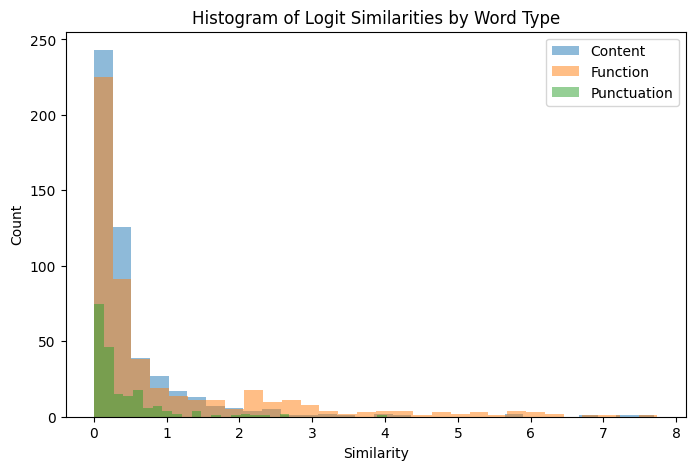

In [49]:
import matplotlib.pyplot as plt

# sim_results is a dict with keys 'content', 'function', 'punctuation' mapping to lists of similarity scores
plt.figure(figsize=(8, 5))
plt.hist(sim_results['content'],    bins=30, alpha=0.5, label='Content')
plt.hist(sim_results['function'],   bins=30, alpha=0.5, label='Function')
plt.hist(sim_results['punctuation'], bins=30, alpha=0.5, label='Punctuation')
plt.legend()
plt.xlabel('Similarity')
plt.ylabel('Count')
plt.title('Histogram of Logit Similarities by Word Type')
plt.show()

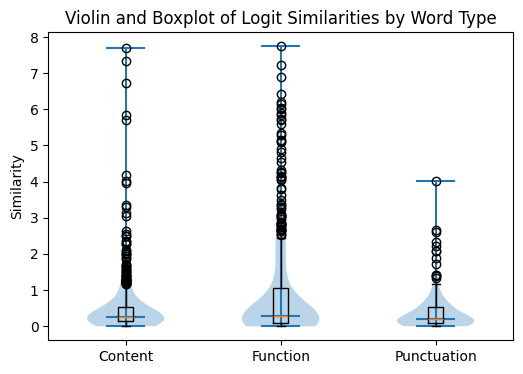

In [50]:
# collect the three lists in order
data = [
    sim_results['content'],
    sim_results['function'],
    sim_results['punctuation']
]
labels = ['Content', 'Function', 'Punctuation']

plt.figure(figsize=(6, 4))
# Violin plot
plt.violinplot(data, positions=[1, 2, 3], showmedians=True)
# Overlay boxplot
plt.boxplot(data, widths=0.1, positions=[1, 2, 3])
plt.xticks([1, 2, 3], labels)
plt.ylabel('Similarity')
plt.title('Violin and Boxplot of Logit Similarities by Word Type')
plt.show()

In [72]:
gain_results = analyzer.run_logit_gain_topN(samples, token_labels, topN=50)

processing: 100%|██████████| 100/100 [07:26<00:00,  4.46s/it]


In [73]:
gain_results

{'content': [{'content': 1.0, 'function': 0.0, 'punctuation': 0.0},
  {'content': 0.9, 'function': 0.1, 'punctuation': 0.0},
  {'content': 0.9, 'function': 0.06, 'punctuation': 0.04},
  {'content': 0.96, 'function': 0.04, 'punctuation': 0.0},
  {'content': 0.94, 'function': 0.06, 'punctuation': 0.0},
  {'content': 0.88, 'function': 0.08, 'punctuation': 0.04},
  {'content': 0.9, 'function': 0.1, 'punctuation': 0.0},
  {'content': 0.82, 'function': 0.16, 'punctuation': 0.02},
  {'content': 0.98, 'function': 0.02, 'punctuation': 0.0},
  {'content': 0.64, 'function': 0.24, 'punctuation': 0.12},
  {'content': 0.9, 'function': 0.1, 'punctuation': 0.0},
  {'content': 0.96, 'function': 0.04, 'punctuation': 0.0},
  {'content': 0.92, 'function': 0.08, 'punctuation': 0.0},
  {'content': 0.76, 'function': 0.24, 'punctuation': 0.0},
  {'content': 0.94, 'function': 0.06, 'punctuation': 0.0},
  {'content': 0.86, 'function': 0.12, 'punctuation': 0.02},
  {'content': 0.82, 'function': 0.1, 'punctuation

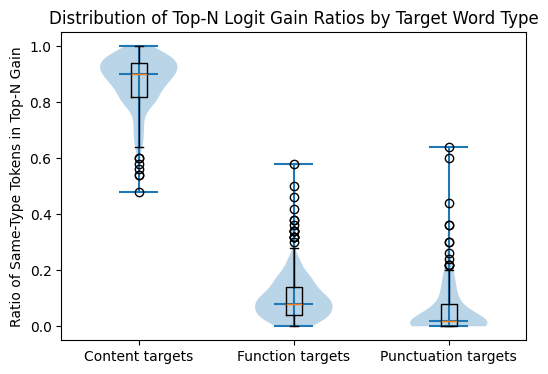

In [74]:
dist_content = [d['content'] for d in gain_results['content']]
dist_function = [d['function'] for d in gain_results['function']]
dist_punctuation = [d['punctuation'] for d in gain_results['punctuation']]

data = [dist_content, dist_function, dist_punctuation]
labels = ['Content targets', 'Function targets', 'Punctuation targets']

plt.figure(figsize=(6, 4))
# Violin plot
plt.violinplot(data, positions=[1,2,3], showmedians=True)
# Overlay boxplot
plt.boxplot(data, widths=0.1, positions=[1,2,3])
plt.xticks([1, 2, 3], labels)
plt.ylabel('Ratio of Same-Type Tokens in Top-N Gain')
plt.title('Distribution of Top-N Logit Gain Ratios by Target Word Type')
plt.show()

In [10]:
# import os
# import json
# import random
# import torch
# import torch.nn.functional as F
# import numpy as np
# from collections import defaultdict
# from typing import List, Dict, Tuple, Any
# import spacy
# from PIL import Image

# # ---------------------------------------------------
# # Data Sampling & Storage
# # ---------------------------------------------------
# class DataSampler:
#     def __init__(self, captions_file: str, sample_size: int = 100, seed: int = 42):
#         """
#         captions_file: JSONL with fields {'image_id', 'caption'}
#         """
#         self.captions_file = captions_file
#         self.sample_size = sample_size
#         random.seed(seed)

#     def sample(self) -> List[Dict[str, Any]]:
#         """
#         Returns a list of samples: each sample is a dict with keys:
#           - 'image_id', 'caption'
#         """
#         all_samples = []
#         with open(self.captions_file) as f:
#             for line in f:
#                 all_samples.append(json.loads(line))
#         random.shuffle(all_samples)
#         return all_samples[: self.sample_size]

# # ---------------------------------------------------
# # Token Classification: function vs content vs punctuation
# # ---------------------------------------------------
# class TokenClassifier:
#     def __init__(self, lang_model: str = 'en_core_web_sm'):
#         self.nlp = spacy.load(lang_model, disable=['parser', 'ner'])
#         # open-class POS for content words
#         self.open_pos = {'NOUN', 'VERB', 'ADJ', 'ADV', 'PROPN'}

#     def classify(self, token) -> str:
#         """Return 'content', 'function', or 'punctuation'."""
#         pos = token.pos_
#         if pos == 'PUNCT':
#             return 'punctuation'
#         if pos in self.open_pos:
#             return 'content'
#         return 'function'

#     def classify_batch(self, samples: List[Dict]) -> Dict[str, Dict[str, List[str]]]:
#         """
#         For each sample, randomly select up to 5 content words, 5 function words, and 2 punctuation tokens.
#         Ensures no duplicates within selections.
#         Returns mapping: image_id -> {'content': [...], 'function': [...], 'punctuation': [...]}.
#         """
#         mapping = {}
#         for s in samples:
#             caption = s['caption']
#             doc = self.nlp(caption)
#             content_cand = []
#             func_cand = []
#             punct_cand = []
#             # Collect candidates
#             for token in doc:
#                 cls = self.classify(token)
#                 text = token.text
#                 if cls == 'content':
#                     content_cand.append(text)
#                 elif cls == 'function':
#                     func_cand.append(text)
#                 else:  # punctuation
#                     punct_cand.append(text)
#             # Remove duplicates while preserving order
#             def unique(lst):
#                 seen = set()
#                 uniq = []
#                 for w in lst:
#                     if w not in seen:
#                         seen.add(w)
#                         uniq.append(w)
#                 return uniq
#             content_cand = unique(content_cand)
#             func_cand = unique(func_cand)
#             punct_cand = unique(punct_cand)
#             # Random sampling
#             content_tokens = random.sample(content_cand, min(5, len(content_cand)))
#             func_tokens = random.sample(func_cand, min(5, len(func_cand)))
#             punct_tokens = random.sample(punct_cand, min(2, len(punct_cand)))
#             mapping[s['image_id']] = {
#                 'content': content_tokens,
#                 'function': func_tokens,
#                 'punctuation': punct_tokens
#             }
#         return mapping

# # ---------------------------------------------------
# # Prefix Truncation Utility
# # ---------------------------------------------------
# class PrefixTruncator:
#     def __init__(self, tokenizer):
#         self.tokenizer = tokenizer

#     def truncate(self, caption: str, target_word: str) -> List[int]:
#         tokens = self.tokenizer.tokenize(caption)
#         # wrap each token in a singleton list
#         words = [ self.tokenizer.convert_tokens_to_string([t]) for t in tokens ]
#         idx = words.index(target_word)   # find the first occurrence
#         # rebuild just the prefix tokens and re-encode
#         prefix_tokens = tokens[:idx]
#         prefix_str = self.tokenizer.convert_tokens_to_string(prefix_tokens)
#         return self.tokenizer(prefix_str, return_tensors='pt').input_ids[0].tolist()

# # ---------------------------------------------------
# # Forward Passes (with/without image) & Logits Extraction
# # ---------------------------------------------------
# class ForwardProcessor:
#     def __init__(self, model, processor, model_type: str):
#         self.model = model.eval()
#         self.processor = processor
#         self.model_type = model_type

#     def run(self,
#             image, prefix_ids: List[int],
#             mask_image: bool = False,
#             output_layers: bool = False
#         ) -> Dict[str, Any]:
#         """
#         Runs a single forward pass and returns:
#           - 'logits': Tensor[V]
#           - If output_layers: 'layer_states': List[Tensor[D]]
#         """
#         inputs = self.processor(images=image, text="", return_tensors='pt').to(self.model.device)
#         inputs['input_ids'] = torch.tensor([prefix_ids], device=self.model.device)
#         if mask_image:
#             inputs['pixel_values'] = inputs['pixel_values'] * 0
#         with torch.no_grad():
#             outputs = self.model(
#                 **inputs,
#                 output_hidden_states=output_layers,
#                 return_dict=True
#             )
#         result = {}
#         lm_out = (outputs.language_model_outputs
#                   if hasattr(outputs, 'language_model_outputs') else outputs)
#         result['logits'] = lm_out.logits[0, -1, :].cpu()
#         if output_layers:
#             hiddens = lm_out.hidden_states
#             result['layer_states'] = [h[0, -1, :].cpu() for h in hiddens]
#         return result

# # ---------------------------------------------------
# # Analysis Methods
# # ---------------------------------------------------
# class Analyzer:
#     def __init__(self, forwarder: ForwardProcessor, tokenizer):
#         self.fwd = forwarder
#         self.tokenizer = tokenizer

#     def compute_similarity(self, logit_a: torch.Tensor, logit_b: torch.Tensor, measure: str='js') -> float:
#         p = F.softmax(logit_a, dim=-1)
#         q = F.softmax(logit_b, dim=-1)
#         if measure == 'kl':
#             return float(F.kl_div(p.log(), q, reduction='batchmean').item())
#         if measure == 'js':
#             m = 0.5*(p + q)
#             return 0.5*(F.kl_div(p.log(), m, reduction='batchmean') + F.kl_div(q.log(), m, reduction='batchmean')).item()
#         if measure == 'cos':
#             return float(F.cosine_similarity(p, q, dim=0).item())
#         raise ValueError(f"Unknown measure {measure}")

#     def run_logit_similarity(self,
#             samples: List[Dict], token_labels: Dict[str, Dict[str, List[str]]],
#             measure: str='js'
#         ) -> Dict[str, List[float]]:
#         results = {'content': [], 'function': [], 'punctuation': []}
#         for s in samples:
#             img_id = s['image_id']
#             img = Image.open(f"/projects/zzhu20/Mehrdad/AMBER/image/AMBER_{img_id}.jpg").convert("RGB")
            
#             caps = s['caption']
#             labels = token_labels[s['image_id']]
#             prefixer = PrefixTruncator(self.tokenizer)
#             for cls in ['content','function','punctuation']:
#                 for tok in labels[cls]:
#                     prefix = prefixer.truncate(caps, tok)
                    
#                     display(img)
#                     print(prefix, '\t', tok)
                    
#                     r_full = self.fwd.run(img, prefix, mask_image=False)
#                     r_text = self.fwd.run(img, prefix, mask_image=True)
#                     sim = self.compute_similarity(r_full['logits'], r_text['logits'], measure)
#                     results[cls].append(sim)
#         return results

#     def run_logit_gain_topN(self,
#             samples: List[Dict], token_labels: Dict[str, Dict[str, List[str]]],
#             topN: int = 100
#         ) -> Dict[str, float]:
#         raise NotImplementedError

#     def run_layer_stability(self,
#             samples: List[Dict], token_labels: Dict[str, Dict[str, List[str]]],
#             topK: int = 10
#         ) -> Dict[str, List[int]]:
#         raise NotImplementedError
